In [ ]:
import numpy as np
import matplotlib.pyplot as plt



N = 400
n = 5
eta = 0.5
lambda_dc = 0.01
runs = 1000
threshold = 2






def generate_scattering_matrix(N, unitary=False):
    H = np.random.randn(N,N) + 1j*np.random.randn(N,N)
    if unitary:
        Q, _ = np.linalg.qr(H)
        return Q
    eigvals = np.linalg.eigvals(H)
    lambda_max = np.max(np.abs(eigvals))
    H = H / lambda_max
    return H




def target_vector(N, k):
    y = np.zeros(N, dtype=complex)
    y[k] = 1
    return y




def compute_challenge(H, yk):
    C = H.conj().T @ yk
    C = C / np.linalg.norm(C)
    return C




def build_database(H):
    N = H.shape[0]
    challenges = []
    responses = []
    for k in range(N):
        yk = target_vector(N, k)
        Ck = compute_challenge(H, yk)
        challenges.append(Ck)
        responses.append(yk)
    return challenges, responses



def propagate(H, C):
    return H @ C




def photon_detection(y, n, eta, lambda_dc):
    mu = eta * n * np.abs(y)**2 + lambda_dc
    counts = np.random.poisson(mu)
    return counts




def camera_frame(counts):
    

    N = len(counts)
    L = int(np.sqrt(N))

    return counts.reshape((L,L))


def simulate_run(H, challenges, n, eta, lambda_dc):
   

    N = len(challenges)

    k = np.random.randint(N)

    Ck = challenges[k]

    y = propagate(H, Ck)

    counts = photon_detection(y, n, eta, lambda_dc)

    return counts, k




def authentication_score(counts, k):
   
    return counts[k]




def false_rejection_rate(H, challenges, runs, threshold, n, eta, lambda_dc):
    

    rejects = 0

    for _ in range(runs):

        counts, k = simulate_run(H, challenges, n, eta, lambda_dc)

        score = authentication_score(counts, k)

        if score < threshold:
            rejects += 1

    return rejects / runs




###H = generate_scattering_matrix(N)

###challenges, responses = build_database(H)

###counts, k = simulate_run(H, challenges, n, eta, lambda_dc)



#img = camera_frame(counts)

#plt.imshow(img)
#plt.colorbar()
#plt.title("Detected photon counts")
#plt.show()

#print("Target mode :", k)




#rate = false_rejection_rate(
#    H,
#    challenges,
#    runs,
#    threshold,
#    n,
#    eta,
    lambda_dc
#)

#print("False rejection rate :", rate)

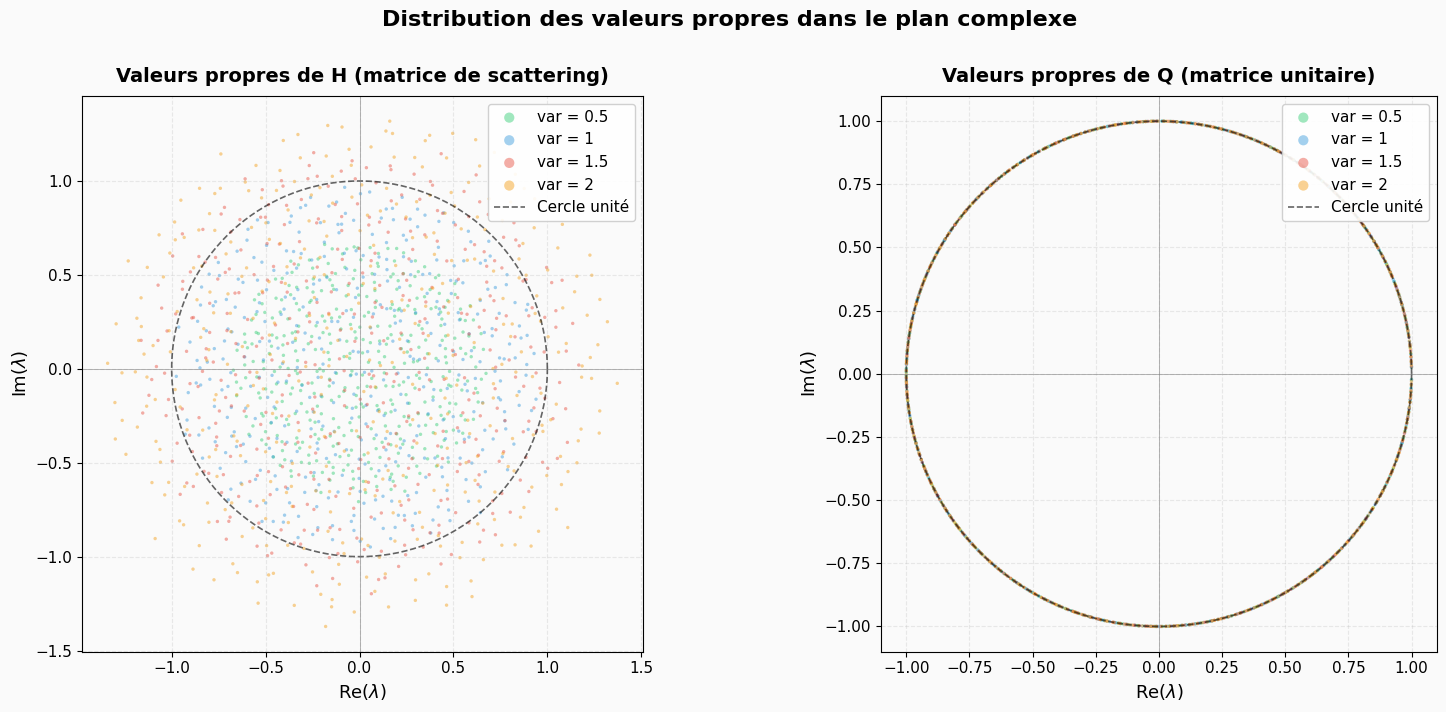

In [7]:
variances = [0.5, 1, 1.5, 2]
colors = ['#2ecc71', '#3498db', '#e74c3c', '#f39c12']

fig, axes = plt.subplots(1, 2, figsize=(16, 7), facecolor='#fafafa')

for i, var in enumerate(variances):
    H = generate_scattering_matrix(N)
    H = H * np.sqrt(var)
    Q, _ = np.linalg.qr(H)
    eigvalsH = np.linalg.eigvals(H)
    eigvalsQ = np.linalg.eigvals(Q)

    axes[0].scatter(eigvalsH.real, eigvalsH.imag, s=6, alpha=0.45,
                    color=colors[i], label=f"var = {var}", edgecolors='none')
    axes[1].scatter(eigvalsQ.real, eigvalsQ.imag, s=6, alpha=0.45,
                    color=colors[i], label=f"var = {var}", edgecolors='none')

theta = np.linspace(0, 2 * np.pi, 300)
for ax in axes:
    ax.plot(np.cos(theta), np.sin(theta), color='black', linewidth=1.2,
            linestyle='--', alpha=0.6, label='Cercle unité')

for ax, title in zip(axes, ["Valeurs propres de H (matrice de scattering)",
                             "Valeurs propres de Q (matrice unitaire)"]):
    ax.set_xlabel(r"Re($\lambda$)", fontsize=13)
    ax.set_ylabel(r"Im($\lambda$)", fontsize=13)
    ax.set_title(title, fontsize=14, fontweight='bold', pad=10)
    ax.legend(fontsize=11, framealpha=0.9, loc='upper right', markerscale=3)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.25, linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.4)
    ax.axvline(0, color='grey', linewidth=0.4)
    ax.set_facecolor('#fafafa')
    ax.tick_params(labelsize=11)

fig.suptitle("Distribution des valeurs propres dans le plan complexe",
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

    

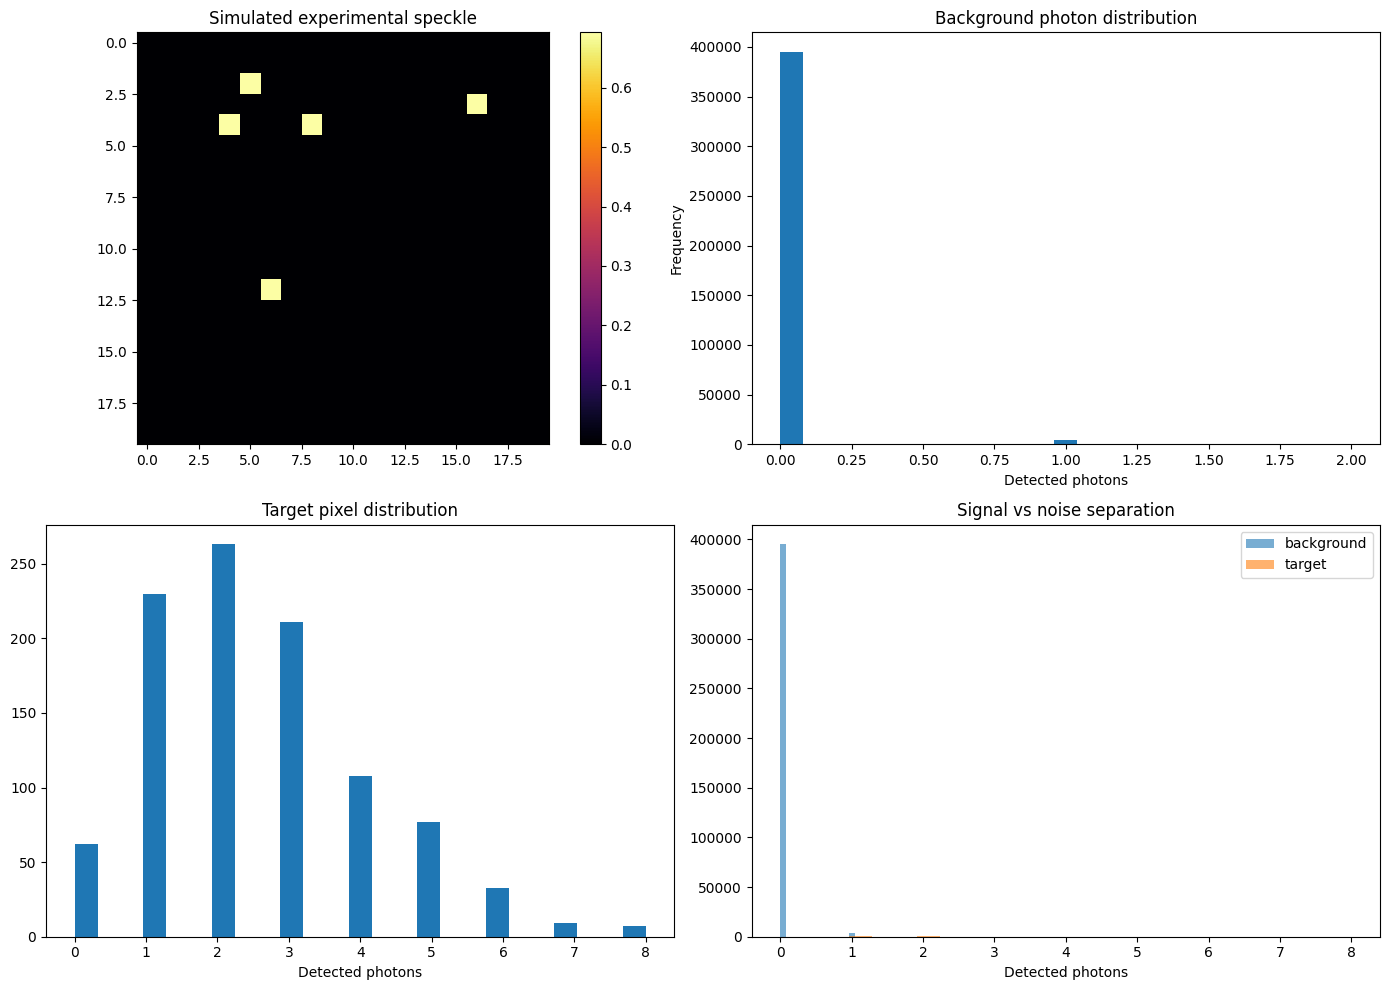

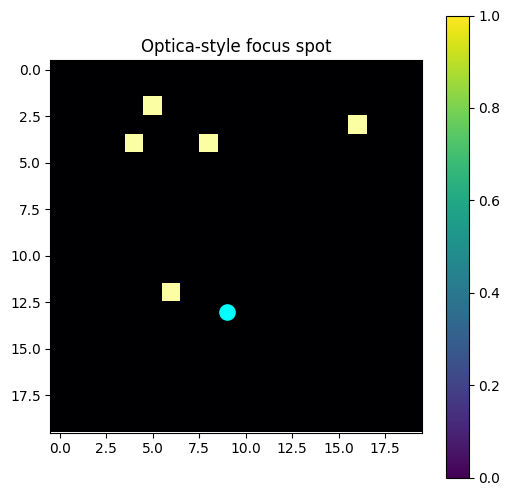

In [3]:


H = generate_scattering_matrix(N,True)

challenges, responses = build_database(H)


counts, k = simulate_run(H, challenges, n, eta, lambda_dc)

img = camera_frame(counts)


scores = []
background = []

for _ in range(runs):

    counts, k = simulate_run(H, challenges, n, eta, lambda_dc)

    scores.append(counts[k])

    background.extend(np.delete(counts, k))




plt.figure(figsize=(14,10))


plt.subplot(2,2,1)

plt.imshow(np.log1p(img), cmap="inferno")

plt.title("Simulated experimental speckle")

plt.colorbar()

plt.subplot(2,2,2)

plt.hist(background, bins=25)

plt.title("Background photon distribution")

plt.xlabel("Detected photons")

plt.ylabel("Frequency")



plt.subplot(2,2,3)

plt.hist(scores, bins=25)

plt.title("Target pixel distribution")

plt.xlabel("Detected photons")



plt.subplot(2,2,4)

plt.hist(background, bins=25, alpha=0.6, label="background")

plt.hist(scores, bins=25, alpha=0.6, label="target")

plt.legend()

plt.title("Signal vs noise separation")

plt.xlabel("Detected photons")

plt.tight_layout()

plt.show()



plt.figure(figsize=(6,6))

plt.imshow(img, cmap="inferno")

L = int(np.sqrt(N))

plt.scatter(k % L, k // L, c="cyan", s=120)

plt.title("Optica-style focus spot")

plt.colorbar()

plt.show()

